In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/raw/rom_rehabilitation_data.csv")
df.loc[0:60]

,patient_id,session_number,date,age,gender,joint_type,treatment_type,rom_degrees,contact_force_n,pain_level,sessions_per_week,initial_rom,target_rom,rom_improvement,percent_improvement,weeks_in_treatment
0,P001,1,2023-03-16,63,F,ankle,Combined,26.0,2.86,8.3,2,26.0,41.6,0.0,0.0,1
1,P001,2,2023-03-23,63,F,ankle,Combined,26.0,6.33,8.3,2,26.0,41.6,0.0,0.0,2
2,P001,3,2023-03-30,63,F,ankle,Combined,28.0,4.40,5.9,4,26.0,41.6,2.0,12.8,3
3,P001,4,2023-04-06,63,F,ankle,Combined,28.1,3.40,5.4,3,26.0,41.6,2.1,13.5,4
4,P001,5,2023-04-13,63,F,ankle,Combined,30.2,4.80,6.3,3,26.0,41.6,4.2,26.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,P005,9,2023-04-27,32,M,wrist,Exercise-Based,60.8,3.54,3.4,2,47.0,80.0,13.8,41.8,9
57,P005,10,2023-05-04,32,M,wrist,Exercise-Based,60.7,2.03,2.9,2,47.0,80.0,13.7,41.5,10
58,P005,11,2023-05-11,32,M,wrist,Exercise-Based,65.6,2.30,2.8,2,47.0,80.0,18.6,56.4,11
59,P005,12,2023-05-18,32,M,wrist,Exercise-Based,66.5,5.47,1.3,3,47.0,80.0,19.5,59.1,12


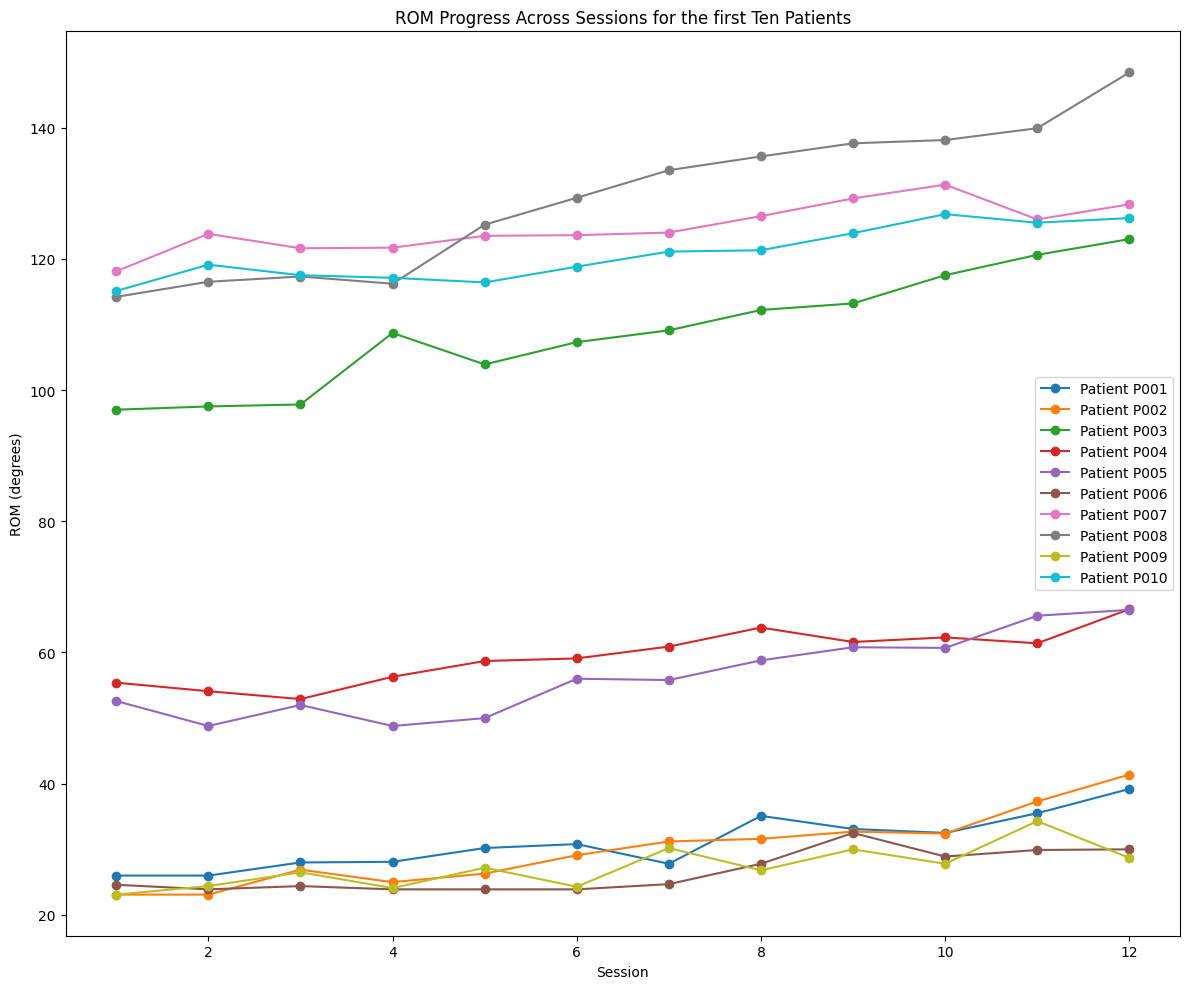

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

# get unique patients
patients = df["patient_id"].unique()[:10]  # Plot only the first 10 patients for clarity

for patient in patients:
    patient_data = df[df["patient_id"] == patient]
    ax.plot(patient_data["session_number"], patient_data["rom_degrees"], marker="o", label=f"Patient {patient}")

ax.set_xlabel("Session")
ax.set_ylabel("ROM (degrees)")
ax.set_title("ROM Progress Across Sessions for the first Ten Patients")
ax.legend()

plt.tight_layout()
plt.savefig("../figures/timeseries_first10_patients.png", dpi=300, bbox_inches='tight')
plt.show()

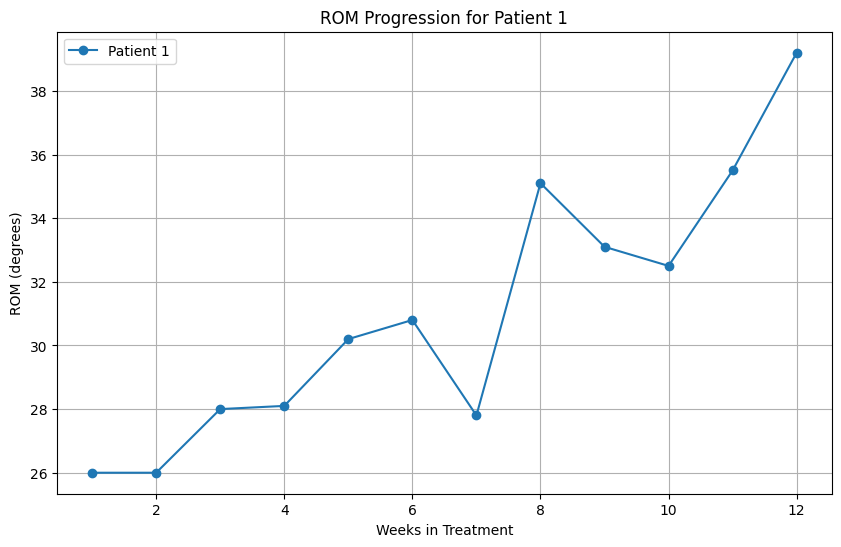

In [7]:
fig,ax = plt.subplots(figsize=(10,6))
ax.plot(df.loc[0:11, "weeks_in_treatment"], df.loc[0:11,"rom_degrees"], marker='o')
ax.set_title("ROM Progression for Patient 1")
ax.set_xlabel("Weeks in Treatment")
ax.set_ylabel("ROM (degrees)")
ax.grid()
ax.legend(["Patient 1"])
fig.savefig("../figures/patient_1_rom_progression.png")


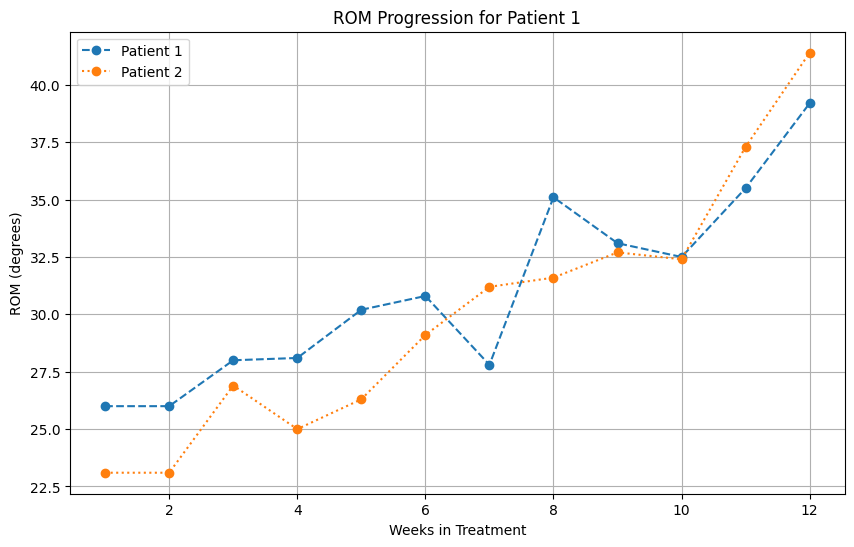

In [8]:
fig,ax = plt.subplots(figsize=(10,6))
ax.plot(df.loc[0:11, "weeks_in_treatment"], df.loc[0:11,"rom_degrees"], marker='o', label="Patient 1", linestyle='--')
ax.plot(df.loc[12:23, "weeks_in_treatment"], df.loc[12:23,"rom_degrees"], marker='o',label="Patient 2", linestyle=":")
ax.set_title("ROM Progression for Patient 1")
ax.set_xlabel("Weeks in Treatment")
ax.set_ylabel("ROM (degrees)")
ax.grid()
ax.legend()
fig.savefig("../figures/patient_1_2_rom_progression.png")

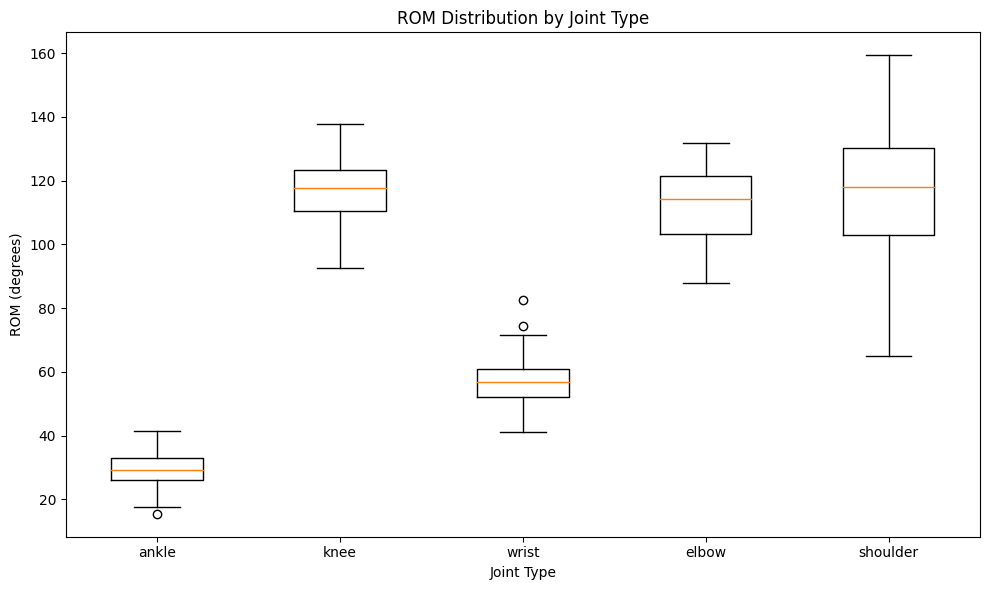

In [9]:
# get unique joint types
joint_types = df["joint_type"].unique()

# group ROM values by joint type
grouped_data = [df[df["joint_type"] == joint]["rom_degrees"].values for joint in joint_types]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(grouped_data, labels=joint_types)

ax.set_xlabel("Joint Type")
ax.set_ylabel("ROM (degrees)")
ax.set_title("ROM Distribution by Joint Type")

plt.tight_layout()
plt.savefig("../figures/boxplot_rom_joint.png", dpi=300, bbox_inches='tight')
plt.show()

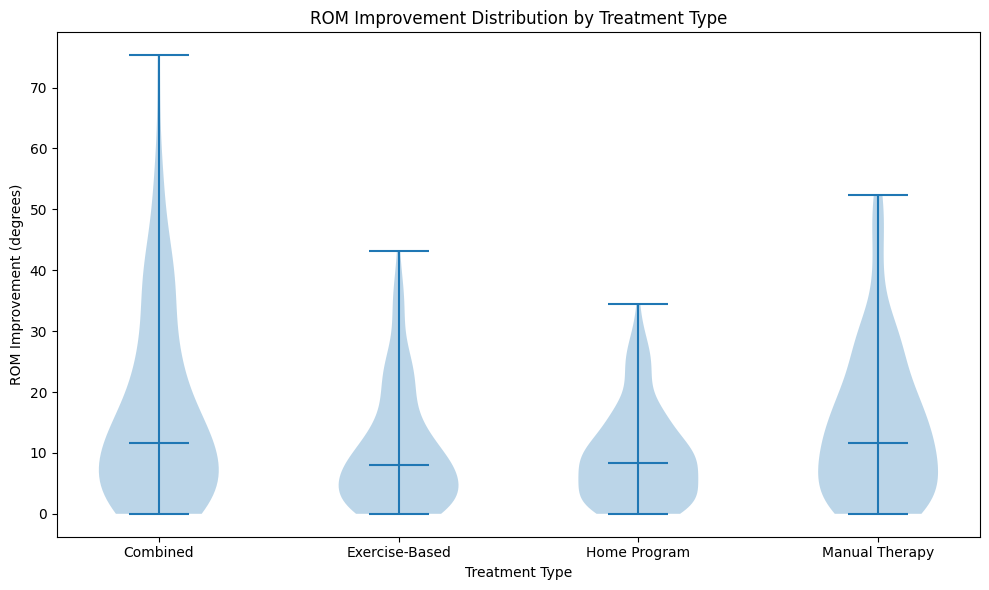

In [10]:
# get unique treatment types
treatment_types = df["treatment_type"].unique()

# group ROM improvement values by treatment type
grouped_data = [df[df["treatment_type"] == treatment]["rom_improvement"].values for treatment in treatment_types]

fig, ax = plt.subplots(figsize=(10, 6))

violin = ax.violinplot(grouped_data, positions=range(len(treatment_types)), showmedians=True)

ax.set_xticks(range(len(treatment_types)))
ax.set_xticklabels(treatment_types)
ax.set_xlabel("Treatment Type")
ax.set_ylabel("ROM Improvement (degrees)")
ax.set_title("ROM Improvement Distribution by Treatment Type")

plt.tight_layout()
plt.savefig("../figures/violin_rom_treatment.png", dpi=300, bbox_inches='tight')
plt.show()

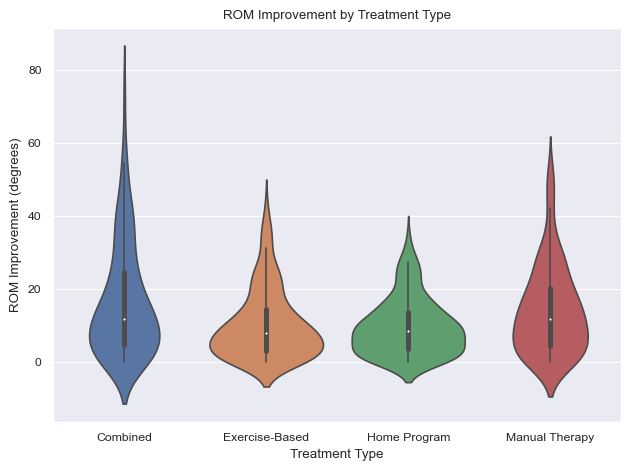

In [11]:
sns.set_theme()
sns.set_context("paper", font_scale=1.0)
# Create a visualization

sns.violinplot(x="treatment_type", y="rom_improvement", data=df)
plt.title("ROM Improvement by Treatment Type")
plt.xlabel("Treatment Type")
plt.ylabel("ROM Improvement (degrees)")
plt.tight_layout()
plt.savefig("../figures/seaborn_violin_rom_treatment.png", dpi=300, bbox_inches='tight')

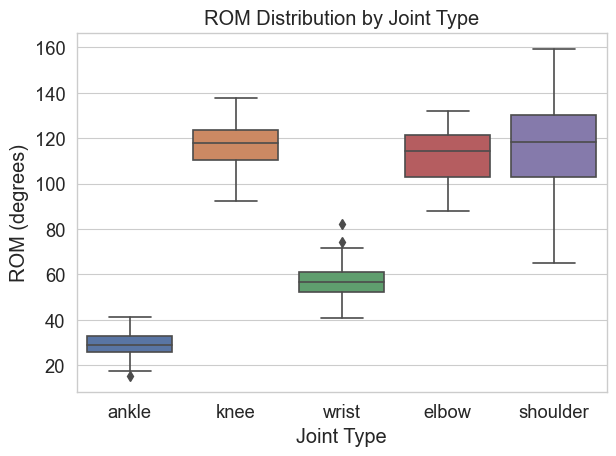

In [12]:
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
# Create a visualization
sns.boxplot(x="joint_type", y="rom_degrees", data=df)
plt.title("ROM Distribution by Joint Type")
plt.xlabel("Joint Type")
plt.ylabel("ROM (degrees)")
plt.tight_layout()
plt.savefig("../figures/seaborn_boxplot_rom_joint.png", dpi=300, bbox_inches='tight')


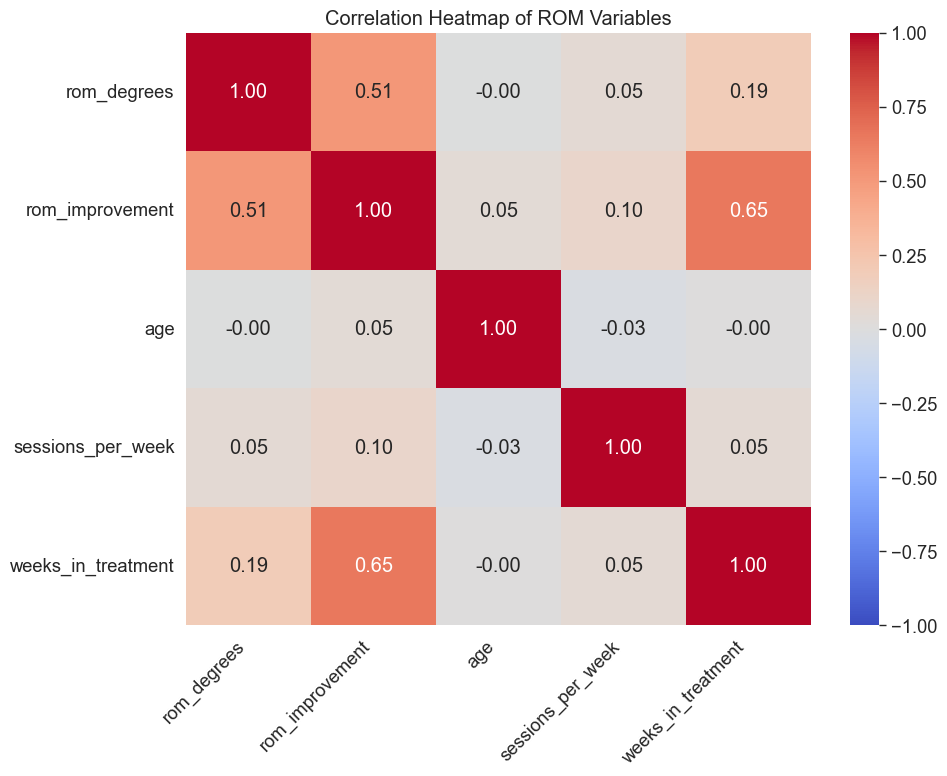

In [13]:
# Correlation heatmap
# step 1 — select numeric columns only
numeric_cols = df[["rom_degrees", "rom_improvement", "age", "sessions_per_week", "weeks_in_treatment"]]

# step 2 — calculate correlation matrix
correlation_matrix = numeric_cols.corr()

# step 3 — plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,        # shows correlation numbers inside each cell
    fmt=".2f",         # rounds numbers to 2 decimal places
    cmap="coolwarm",   # color scheme
    vmin=-1, vmax=1,   # fixes color scale from -1 to 1
    ax=ax
)

ax.set_title("Correlation Heatmap of ROM Variables")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=300, bbox_inches='tight')



## What `.corr()` produces:

# It calculates the correlation between every pair of numeric columns and returns a matrix:
# ```
#                       rom_degrees  rom_improvement  age   weight_kg
# rom_degrees               1.00          0.85       -0.30    0.12
# rom_improvement           0.85          1.00       -0.25    0.08
# age                      -0.30         -0.25        1.00    0.45
# weight_kg                 0.12          0.08        0.45    1.00
# ```

# The heatmap then colors each cell based on its value.

# ---

# ## How to read the colors:
# ```
#   -1.0        0.0        +1.0
#    ↑           ↑           ↑
#   blue        white       red

# strong      no          strong
# negative    relationship positive
# correlation             correlation

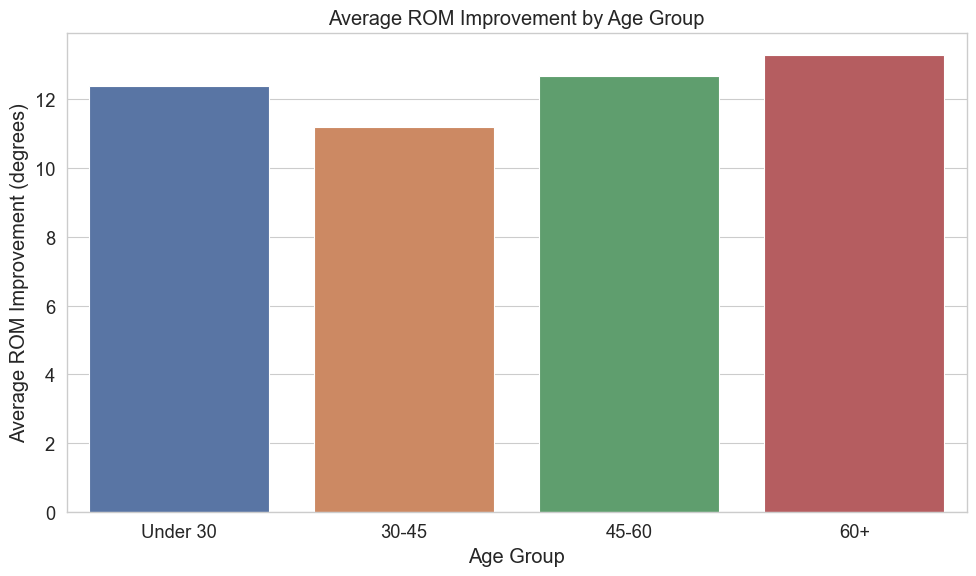

In [14]:
#Bar plot of average ROM improvement by age group
# step 1 — create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Under 30", "30-45", "45-60", "60+"]
)

# step 2 — calculate average ROM improvement per age group
avg_rom = df.groupby("age_group")["rom_improvement"].mean().reset_index()

# step 3 — plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=avg_rom, x="age_group", y="rom_improvement", ax=ax)

ax.set_xlabel("Age Group")
ax.set_ylabel("Average ROM Improvement (degrees)")
ax.set_title("Average ROM Improvement by Age Group")


plt.tight_layout()
plt.savefig("../figures/barplot_rom_age_group.png", dpi=300, bbox_inches='tight')


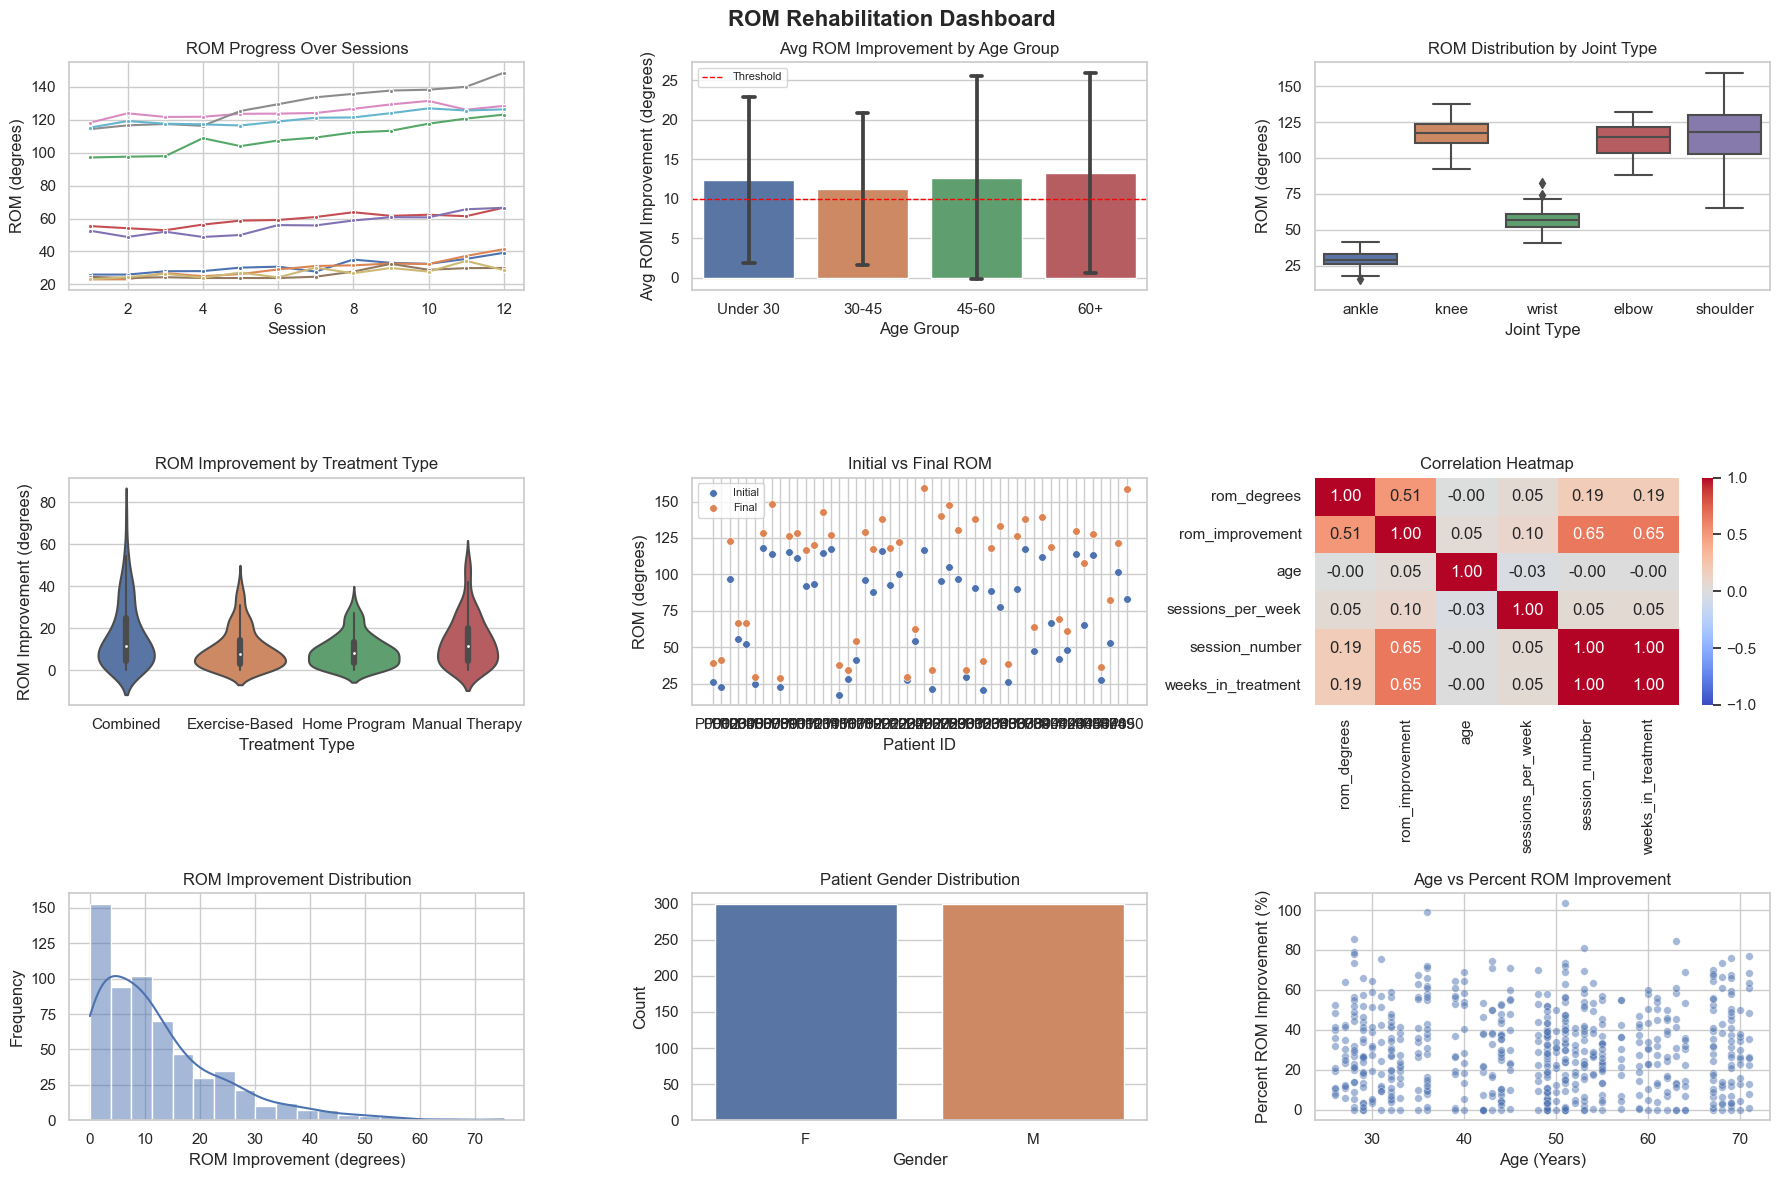

In [15]:


sns.set_theme(style="whitegrid")  # applies clean seaborn styling to all plots

fig = plt.figure(figsize=(18, 12))
fig.suptitle("ROM Rehabilitation Dashboard", fontsize=16, fontweight="bold")

# ── plot 1: top-left — time series ROM progress ──────────────────
ax1 = fig.add_subplot(3, 3, 1)
sns.lineplot(data=df[df["patient_id"].isin(df["patient_id"].unique()[:10])],
             x="session_number", y="rom_degrees", hue="patient_id",
             marker="o", markersize=3, legend=False, ax=ax1)
ax1.set_title("ROM Progress Over Sessions")
ax1.set_xlabel("Session")
ax1.set_ylabel("ROM (degrees)")

# ── plot 2: top-middle — average ROM improvement by age group ─────
ax2 = fig.add_subplot(3, 3, 2)
sns.barplot(data=df, x="age_group", y="rom_improvement", ax=ax2, errorbar="sd", capsize=0.1)
ax2.axhline(y=10, color="red", linestyle="--", linewidth=1, label="Threshold")
ax2.set_title("Avg ROM Improvement by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Avg ROM Improvement (degrees)")
ax2.legend(fontsize=8)

# ── plot 3: top-right — boxplot ROM by joint type ─────────────────
ax3 = fig.add_subplot(3, 3, 3)
sns.boxplot(data=df, x="joint_type", y="rom_degrees", ax=ax3)
ax3.set_title("ROM Distribution by Joint Type")
ax3.set_xlabel("Joint Type")
ax3.set_ylabel("ROM (degrees)")

# ── plot 4: middle-left — violin plot ROM by treatment type ───────
ax4 = fig.add_subplot(3, 3, 4)
sns.violinplot(data=df, x="treatment_type", y="rom_improvement", ax=ax4)
ax4.set_title("ROM Improvement by Treatment Type")
ax4.set_xlabel("Treatment Type")
ax4.set_ylabel("ROM Improvement (degrees)")

# ── plot 5: middle-middle — scatter initial vs final ROM ──────────
ax5 = fig.add_subplot(3, 3, 5)
initial = df[df["session_number"] == 1]
final = df[df["session_number"] == 12]
sns.scatterplot(data=initial, x="patient_id", y="rom_degrees", label="Initial", ax=ax5, s=30)
sns.scatterplot(data=final, x="patient_id", y="rom_degrees", label="Final", ax=ax5, s=30)
ax5.set_title("Initial vs Final ROM")
ax5.set_xlabel("Patient ID")
ax5.set_ylabel("ROM (degrees)")
ax5.legend(fontsize=8)

# ── plot 6: middle-right — correlation heatmap ───────────────────
ax6 = fig.add_subplot(3, 3, 6)
numeric_cols = df[["rom_degrees", "rom_improvement", "age", "sessions_per_week", "session_number", "weeks_in_treatment"]]
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax6)
ax6.set_title("Correlation Heatmap")

# ── plot 7: bottom-left — ROM improvement distribution ───────────
ax7 = fig.add_subplot(3, 3, 7)
sns.histplot(data=df, x="rom_improvement", bins=20, kde=True, ax=ax7)
ax7.set_title("ROM Improvement Distribution")
ax7.set_xlabel("ROM Improvement (degrees)")
ax7.set_ylabel("Frequency")

# ── plot 8: bottom-middle — gender count ─────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
sns.countplot(data=df, x="gender", ax=ax8)
ax8.set_title("Patient Gender Distribution")
ax8.set_xlabel("Gender")
ax8.set_ylabel("Count")

# ── plot 9: bottom-right — Age vs rehab time ──────────────────
ax9 = fig.add_subplot(3, 3, 9)
sns.scatterplot(data=df, x="age", y="percent_improvement", alpha=0.5, s=30, ax=ax9)
ax9.set_title("Age vs Percent ROM Improvement")
ax9.set_xlabel("Age (Years)")
ax9.set_ylabel("Percent ROM Improvement (%)")

plt.tight_layout()
plt.savefig("../figures/rom_dashboard_sns.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
df[0:5]

,patient_id,session_number,date,age,gender,joint_type,treatment_type,rom_degrees,contact_force_n,pain_level,sessions_per_week,initial_rom,target_rom,rom_improvement,percent_improvement,weeks_in_treatment,age_group
0,P001,1,2023-03-16,63,F,ankle,Combined,26.0,2.86,8.3,2,26.0,41.6,0.0,0.0,1,60+
1,P001,2,2023-03-23,63,F,ankle,Combined,26.0,6.33,8.3,2,26.0,41.6,0.0,0.0,2,60+
2,P001,3,2023-03-30,63,F,ankle,Combined,28.0,4.40,5.9,4,26.0,41.6,2.0,12.8,3,60+
3,P001,4,2023-04-06,63,F,ankle,Combined,28.1,3.40,5.4,3,26.0,41.6,2.1,13.5,4,60+
4,P001,5,2023-04-13,63,F,ankle,Combined,30.2,4.80,6.3,3,26.0,41.6,4.2,26.9,5,60+


In [82]:
a, b = 0,1
while a < 10:
    print(a)
    a,b = b, a+b

0
1
1
2
3
5
8
